In [1]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [2]:
import os
os.makedirs('/content/drive/MyDrive/airline_lab', exist_ok=True)
%cd /content/drive/MyDrive/airline_lab

/content/drive/MyDrive/airline_lab


In [ ]:
from google.colab import userdata
import os

kaggle_token = userdata.get('KAGGLE_TOKEN')

# Configure Kaggle credentials folder
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    f.write('{"username":"REPLACE_WITH_YOUR_USERNAME","key":"' + kaggle_token + '"}')

!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle credentials configured securely!")

In [3]:
!pip install kaggle -q
!kaggle datasets download -d crowdflower/twitter-airline-sentiment
!unzip -q twitter-airline-sentiment.zip -d data
!ls data/

Dataset URL: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment
License(s): CC-BY-NC-SA-4.0
100% 2.55M/2.55M [00:01<00:00, 2.06MB/s]

database.sqlite  Tweets.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [5]:
df = pd.read_csv('data/Tweets.csv')
print(df.shape)

(14640, 15)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

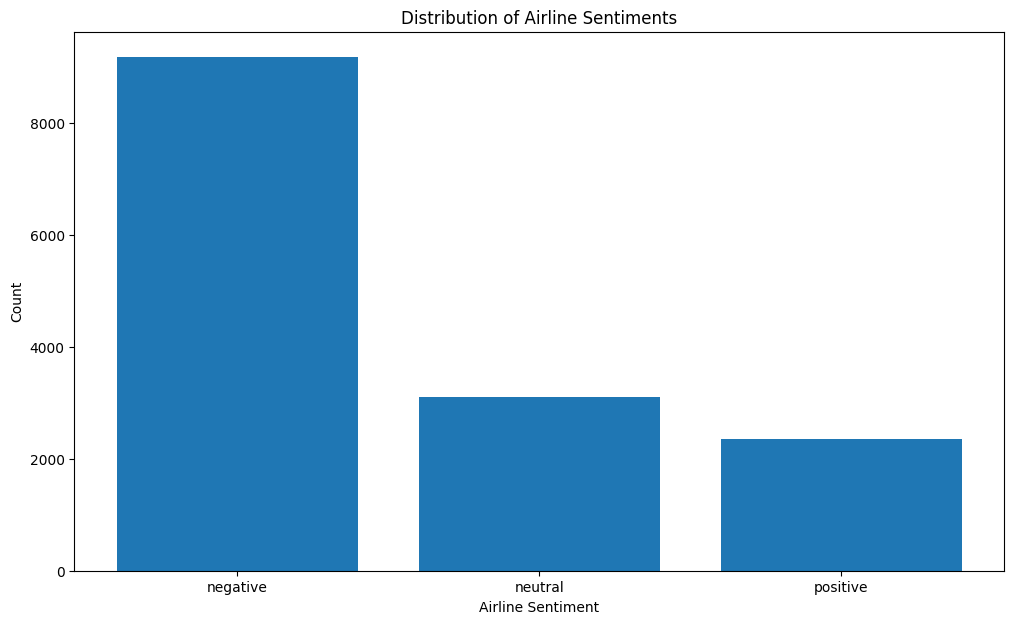

In [7]:
plt.figure(figsize=(12, 7))
plt.bar(df['airline_sentiment'].value_counts().index, df['airline_sentiment'].value_counts().values)
plt.title('Distribution of Airline Sentiments')
plt.xlabel('Airline Sentiment')
plt.ylabel('Count')
plt.show()

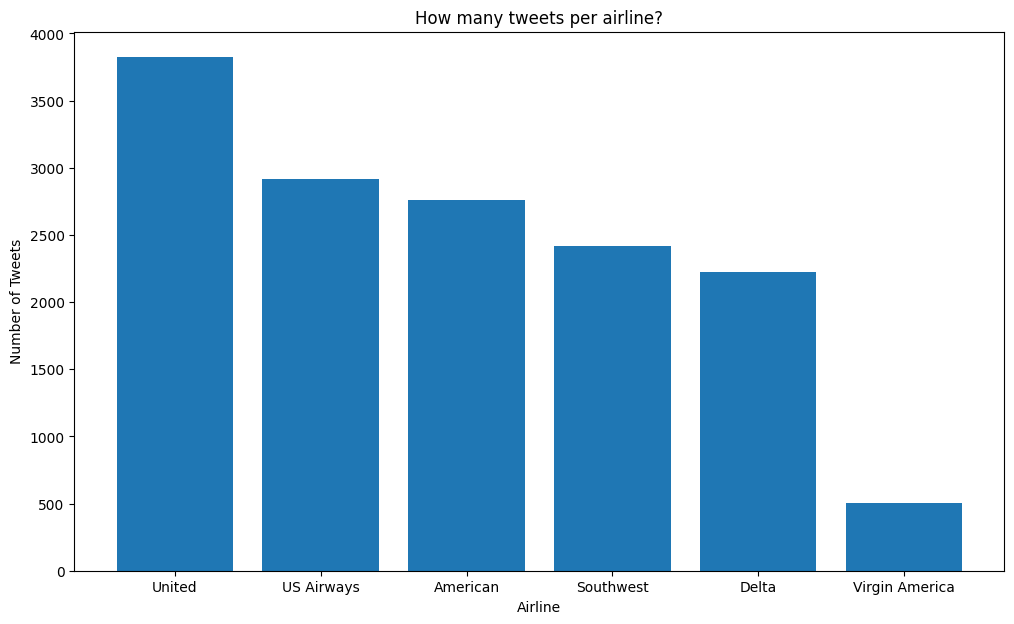

In [8]:
plt.figure(figsize=(12, 7))
plt.bar(df['airline'].value_counts().index, df['airline'].value_counts().values)
plt.title("How many tweets per airline?")
plt.xlabel("Airline")
plt.ylabel("Number of Tweets")
plt.show()

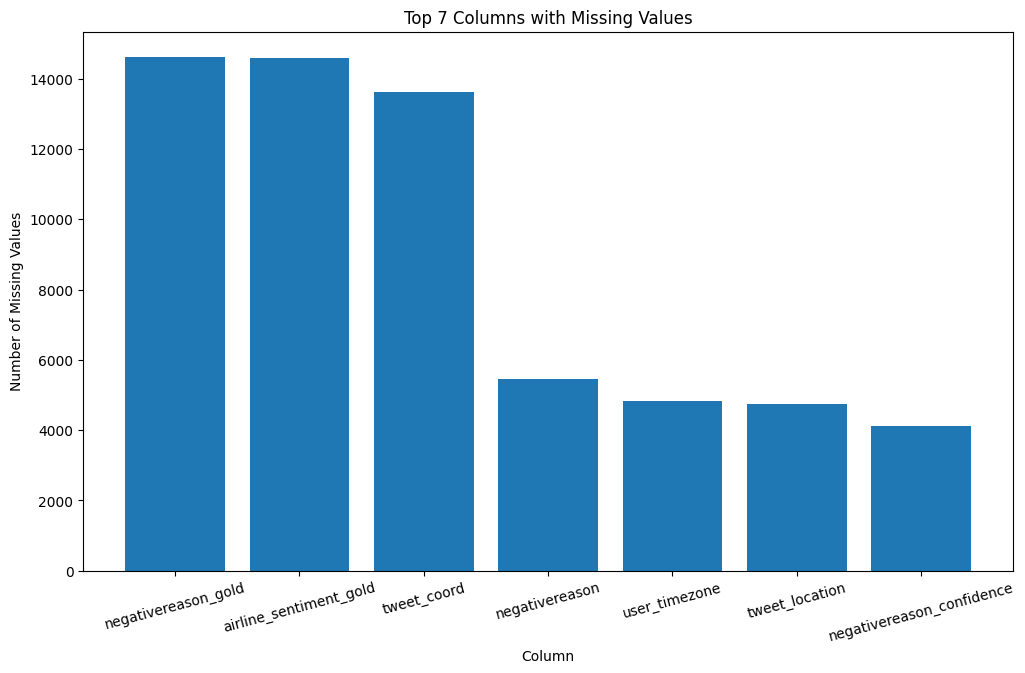

In [9]:
plt.figure(figsize=(12, 7))
missing_counts = df.isnull().sum()
top_7_missing_cols = missing_counts.nlargest(7)
plt.bar(top_7_missing_cols.index, top_7_missing_cols.values)
plt.xticks(rotation=15)
plt.title('Top 7 Columns with Missing Values')
plt.xlabel('Column')
plt.ylabel('Number of Missing Values')
plt.show()

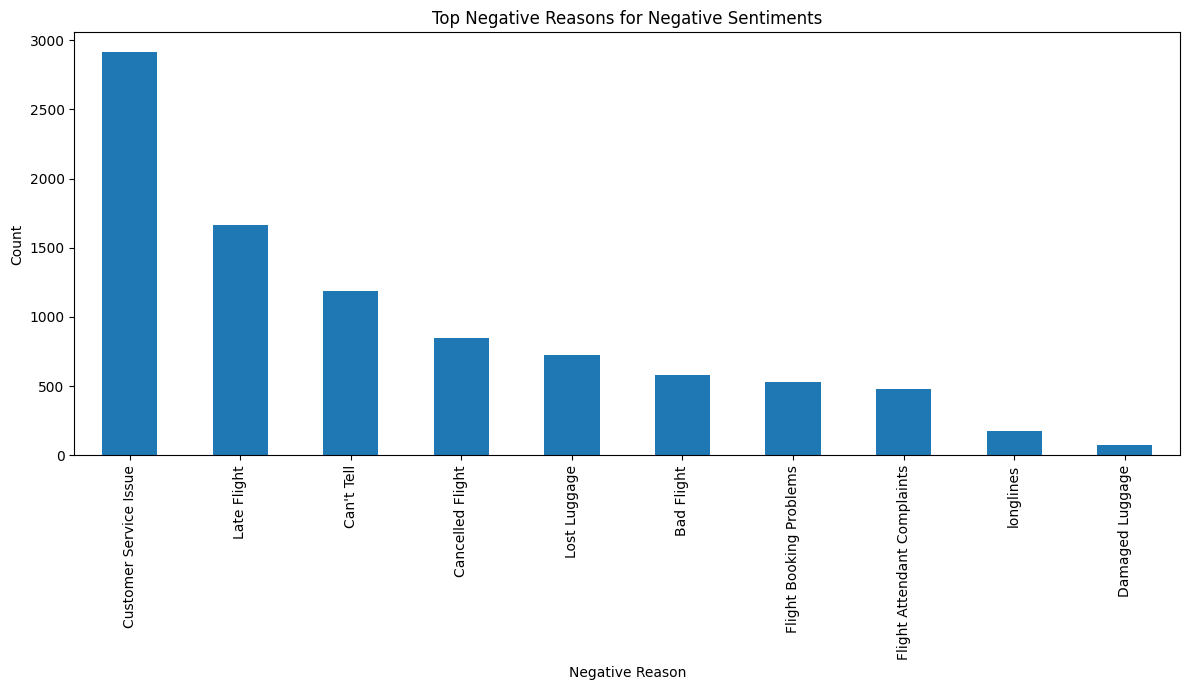

In [10]:
plt.figure(figsize=(12, 7))
df[df['airline_sentiment'] == 'negative']['negativereason'].value_counts().plot.bar()
plt.title('Top Negative Reasons for Negative Sentiments')
plt.xlabel('Negative Reason')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [11]:
tweets = pd.read_csv('data/Tweets.csv')
tweets.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [12]:
tweets.shape

(14640, 15)

In [13]:
tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [14]:
tweets['tweet_created'] = pd.to_datetime(tweets['tweet_created'], errors='coerce', utc=True)
tweets['tweet_created'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 14640 entries, 0 to 14639
Series name: tweet_created
Non-Null Count  Dtype              
--------------  -----              
14640 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1)
memory usage: 114.5 KB


In [15]:
tweets.isna().sum().sort_values(ascending=False)

,0
negativereason_gold,14608
airline_sentiment_gold,14600
tweet_coord,13621
negativereason,5462
user_timezone,4820
tweet_location,4733
negativereason_confidence,4118
airline,0
tweet_id,0
airline_sentiment,0


In [16]:
tweets = tweets.drop(columns=['tweet_coord', 'airline_sentiment_gold', 'negativereason_gold', 'tweet_location'])

In [17]:
tweets.duplicated().sum()

tweets.drop_duplicates()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 19:35:52+00:00,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 19:15:59+00:00,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 19:15:48+00:00,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 19:15:36+00:00,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 19:14:45+00:00,Pacific Time (US & Canada)
...,...,...,...,...,...,...,...,...,...,...,...
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,KristenReenders,0,@AmericanAir thank you we got on a different f...,2015-02-22 20:01:01+00:00,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,itsropes,0,@AmericanAir leaving over 20 minutes Late Flig...,2015-02-22 19:59:46+00:00,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,sanyabun,0,@AmericanAir Please bring American Airlines to...,2015-02-22 19:59:15+00:00,NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,SraJackson,0,"@AmericanAir you have my money, you change my ...",2015-02-22 19:59:02+00:00,Eastern Time (US & Canada)


In [18]:
tweets.to_parquet('/content/drive/MyDrive/airline_lab/tweets_step1.parquet')

Text(0, 0.5, 'Number of tweets')

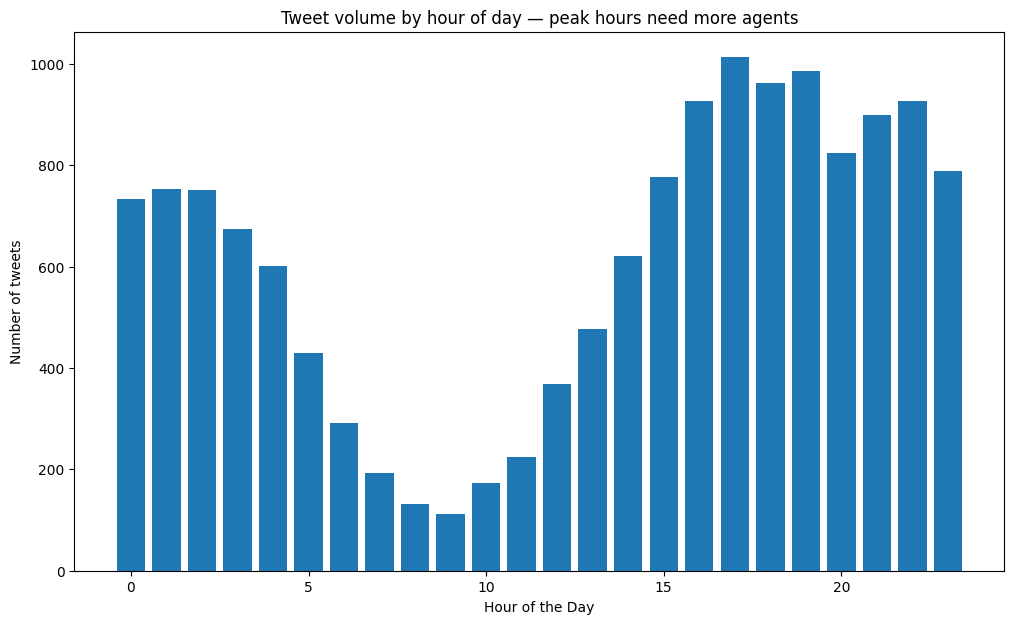

In [19]:
tweets['tweet_hour'] = tweets['tweet_created'].dt.hour
tweets.groupby('tweet_hour').size()

plt.figure(figsize=(12, 7))
plt.bar(tweets['tweet_hour'].value_counts().index, tweets['tweet_hour'].value_counts().values)
plt.title('Tweet volume by hour of day — peak hours need more agents')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of tweets')

In [20]:
tweets = pd.read_parquet('/content/drive/MyDrive/airline_lab/tweets_step1.parquet')

In [21]:
tweets.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,user_timezone
0,570306133677760513,neutral,1.0000,None,NaN,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 19:35:52+00:00,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,None,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 19:15:59+00:00,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,None,NaN,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 19:15:48+00:00,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 19:15:36+00:00,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 19:14:45+00:00,Pacific Time (US & Canada)


Text(0, 0.5, 'Frequency')

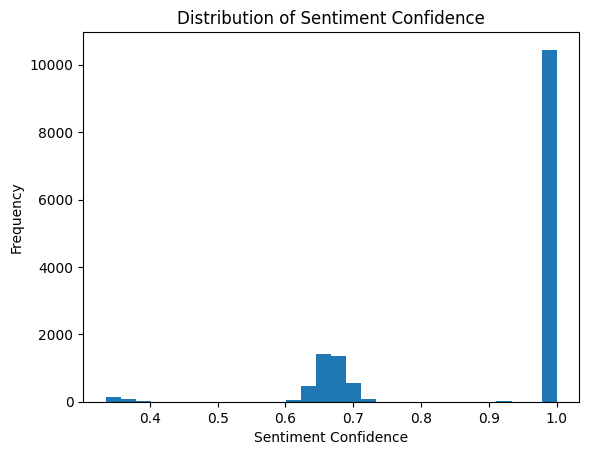

In [22]:
plt.hist(tweets['airline_sentiment_confidence'], bins=30)
plt.title('Distribution of Sentiment Confidence')
plt.xlabel('Sentiment Confidence')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

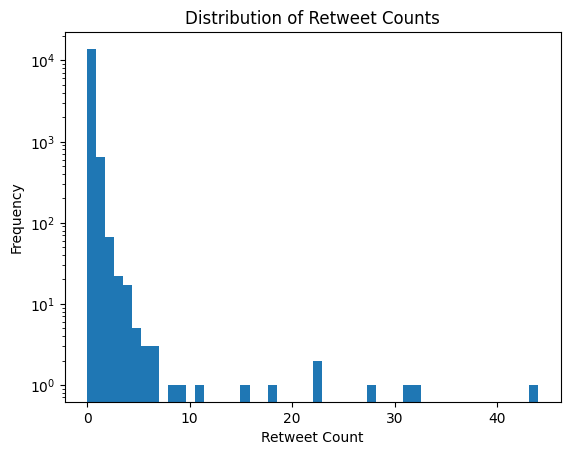

In [23]:
plt.hist(tweets['retweet_count'], bins=50)
plt.yscale('log')
plt.title('Distribution of Retweet Counts')
plt.xlabel('Retweet Count')
plt.ylabel('Frequency')

In [24]:
tweets = pd.get_dummies(tweets, columns=['airline'], prefix='airline')
tweets.head()


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,name,retweet_count,text,tweet_created,user_timezone,airline_American,airline_Delta,airline_Southwest,airline_US Airways,airline_United,airline_Virgin America
0,570306133677760513,neutral,1.0000,None,NaN,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 19:35:52+00:00,Eastern Time (US & Canada),False,False,False,False,False,True
1,570301130888122368,positive,0.3486,None,0.0000,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 19:15:59+00:00,Pacific Time (US & Canada),False,False,False,False,False,True
2,570301083672813571,neutral,0.6837,None,NaN,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 19:15:48+00:00,Central Time (US & Canada),False,False,False,False,False,True
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 19:15:36+00:00,Pacific Time (US & Canada),False,False,False,False,False,True
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 19:14:45+00:00,Pacific Time (US & Canada),False,False,False,False,False,True


In [25]:
tweets = pd.get_dummies(tweets, columns=['negativereason'], prefix='reason')
tweets.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason_confidence,name,retweet_count,text,tweet_created,user_timezone,airline_American,...,reason_Bad Flight,reason_Can't Tell,reason_Cancelled Flight,reason_Customer Service Issue,reason_Damaged Luggage,reason_Flight Attendant Complaints,reason_Flight Booking Problems,reason_Late Flight,reason_Lost Luggage,reason_longlines
0,570306133677760513,neutral,1.0000,NaN,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 19:35:52+00:00,Eastern Time (US & Canada),False,...,False,False,False,False,False,False,False,False,False,False
1,570301130888122368,positive,0.3486,0.0000,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 19:15:59+00:00,Pacific Time (US & Canada),False,...,False,False,False,False,False,False,False,False,False,False
2,570301083672813571,neutral,0.6837,NaN,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 19:15:48+00:00,Central Time (US & Canada),False,...,False,False,False,False,False,False,False,False,False,False
3,570301031407624196,negative,1.0000,0.7033,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 19:15:36+00:00,Pacific Time (US & Canada),False,...,True,False,False,False,False,False,False,False,False,False
4,570300817074462722,negative,1.0000,1.0000,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 19:14:45+00:00,Pacific Time (US & Canada),False,...,False,True,False,False,False,False,False,False,False,False


In [26]:
tweets['airline_sentiment'] = tweets['airline_sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})
tweets.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason_confidence,name,retweet_count,text,tweet_created,user_timezone,airline_American,...,reason_Bad Flight,reason_Can't Tell,reason_Cancelled Flight,reason_Customer Service Issue,reason_Damaged Luggage,reason_Flight Attendant Complaints,reason_Flight Booking Problems,reason_Late Flight,reason_Lost Luggage,reason_longlines
0,570306133677760513,1,1.0000,NaN,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 19:35:52+00:00,Eastern Time (US & Canada),False,...,False,False,False,False,False,False,False,False,False,False
1,570301130888122368,2,0.3486,0.0000,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 19:15:59+00:00,Pacific Time (US & Canada),False,...,False,False,False,False,False,False,False,False,False,False
2,570301083672813571,1,0.6837,NaN,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 19:15:48+00:00,Central Time (US & Canada),False,...,False,False,False,False,False,False,False,False,False,False
3,570301031407624196,0,1.0000,0.7033,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 19:15:36+00:00,Pacific Time (US & Canada),False,...,True,False,False,False,False,False,False,False,False,False
4,570300817074462722,0,1.0000,1.0000,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 19:14:45+00:00,Pacific Time (US & Canada),False,...,False,True,False,False,False,False,False,False,False,False


In [27]:
tweets['log_retweet'] = np.log1p(tweets['retweet_count'])
tweets.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason_confidence,name,retweet_count,text,tweet_created,user_timezone,airline_American,...,reason_Can't Tell,reason_Cancelled Flight,reason_Customer Service Issue,reason_Damaged Luggage,reason_Flight Attendant Complaints,reason_Flight Booking Problems,reason_Late Flight,reason_Lost Luggage,reason_longlines,log_retweet
0,570306133677760513,1,1.0000,NaN,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 19:35:52+00:00,Eastern Time (US & Canada),False,...,False,False,False,False,False,False,False,False,False,0.0
1,570301130888122368,2,0.3486,0.0000,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 19:15:59+00:00,Pacific Time (US & Canada),False,...,False,False,False,False,False,False,False,False,False,0.0
2,570301083672813571,1,0.6837,NaN,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 19:15:48+00:00,Central Time (US & Canada),False,...,False,False,False,False,False,False,False,False,False,0.0
3,570301031407624196,0,1.0000,0.7033,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 19:15:36+00:00,Pacific Time (US & Canada),False,...,False,False,False,False,False,False,False,False,False,0.0
4,570300817074462722,0,1.0000,1.0000,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 19:14:45+00:00,Pacific Time (US & Canada),False,...,True,False,False,False,False,False,False,False,False,0.0


In [28]:
top5 = tweets['user_timezone'].value_counts().head(5).index
tweets['user_timezone'] = tweets['user_timezone'].where(tweets['user_timezone'].isin(top5), 'other')

In [29]:
tweets.to_parquet('/content/drive/MyDrive/airline_lab/tweets_step2.parquet')

In [30]:
tweets = pd.read_parquet('/content/drive/MyDrive/airline_lab/tweets_step2.parquet')

In [47]:
tweets['tweet_year'] = tweets['tweet_created'].dt.year
tweets['tweet_month'] = tweets['tweet_created'].dt.month
tweets['tweet_day'] = tweets['tweet_created'].dt.day
tweets['tweet_hour'] = tweets['tweet_created'].dt.hour
tweets['is_weekend'] = tweets['tweet_created'].dt.dayofweek >= 5
tweets['tweet_hour'] = tweet_hour

In [48]:
tweets['text_length'] = tweets['text'].str.len()

Text(0.5, 1.0, 'Distribution of Tweet Lengths')

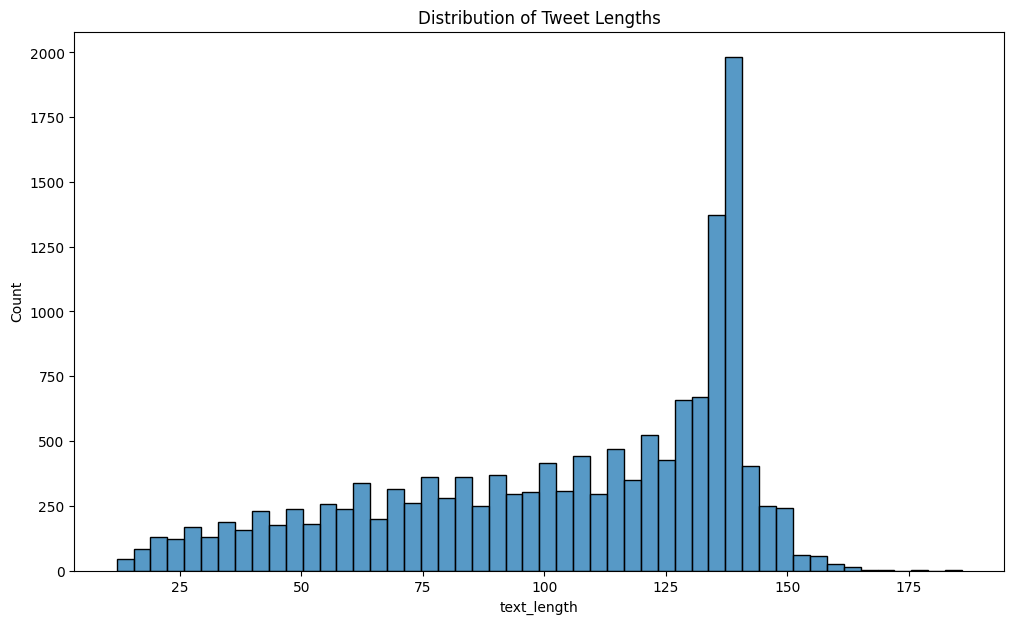

In [33]:
plt.figure(figsize=(12, 7))
sns.histplot(tweets['text_length'], bins=50)
plt.title('Distribution of Tweet Lengths')

<Axes: xlabel='airline_sentiment', ylabel='text_length'>

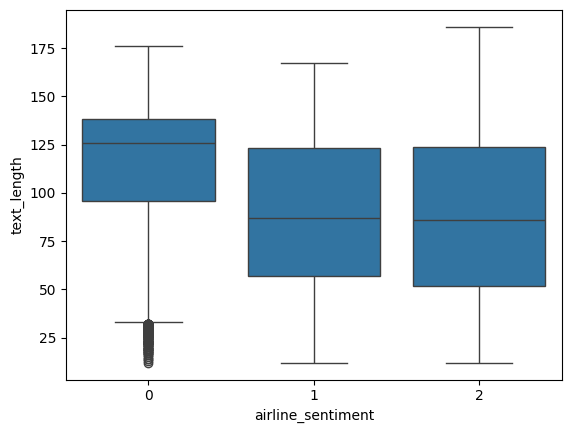

In [34]:
sns.boxplot(x='airline_sentiment', y='text_length', data=tweets)

In [35]:
tweets['n_mentions'] = tweets['text'].str.count('@')
tweets['n_hashtags'] = tweets['text'].str.count('#')
tweets['has_url'] = tweets['text'].str.contains('http').astype(int)
tweets['n_cap_words'] = tweets['text'].str.count(r'\b[A-Z]+\b')
tweets['has_question_mark'] = tweets['text'].str.contains('\?').astype(int)
tweets['has_exclamation_mark'] = tweets['text'].str.contains('!').astype(int)


<>:5: SyntaxWarning: invalid escape sequence '\?'
<>:5: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipykernel_1139/3490893992.py:5: SyntaxWarning: invalid escape sequence '\?'
  tweets['has_question_mark'] = tweets['text'].str.contains('\?').astype(int)


In [36]:
positive_words = ['thank', 'great', 'love', 'awesome', 'amazing', 'best', 'beautiful', 'charming', 'delightful', 'elegant', 'excellent', 'fantastic', 'friendly' 'lovely', 'nice', 'pleasant', 'wonderful']
negative_words = ['worst', 'terrible', 'late', 'lost', 'cancelled', 'awful', 'bad', 'poor', 'unhappy', 'frustrated', 'delayed', 'missed', 'disappointed', 'rude', 'unhelpful', 'inconvenient']

def lexicon_score(text):
  text_lower = text.lower()
  positive_score = sum([1 for word in positive_words if word in text_lower])
  negative_score = sum([1 for word in negative_words if word in text_lower])
  return positive_score - negative_score

tweets['sentiment_lexicon_score'] = tweets['text'].apply(lexicon_score)

In [37]:
tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 34 columns):
 #   Column                              Non-Null Count  Dtype              
---  ------                              --------------  -----              
 0   tweet_id                            14640 non-null  int64              
 1   airline_sentiment                   14640 non-null  int64              
 2   airline_sentiment_confidence        14640 non-null  float64            
 3   negativereason_confidence           10522 non-null  float64            
 4   name                                14640 non-null  object             
 5   retweet_count                       14640 non-null  int64              
 6   text                                14640 non-null  object             
 7   tweet_created                       14640 non-null  datetime64[ns, UTC]
 8   user_timezone                       14640 non-null  object             
 9   airline_American                    146

In [38]:
numeric_cols = ['log_retweet', 'text_length', 'n_mentions', 'n_hashtags', 'has_url', 'n_cap_words', 'has_question_mark', 'has_exclamation_mark', 'sentiment_lexicon_score']

<Axes: >

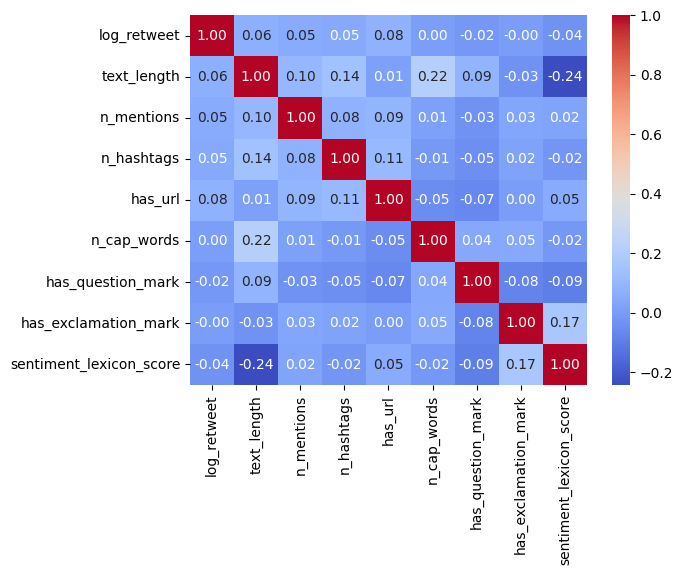

In [39]:
sns.heatmap(tweets[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')

In [40]:
from sklearn.model_selection import train_test_split

X = tweets.drop('airline_sentiment', axis=1)
y = tweets['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [41]:
from sklearn.feature_selection import VarianceThreshold

VarianceThreshold(threshold=0.01).fit_transform(X_train[numeric_cols])

array([[  0.        ,  26.        ,   1.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        , 139.        ,   1.        , ...,   1.        ,
          0.        ,   0.        ],
       [  0.        , 150.        ,   1.        , ...,   0.        ,
          0.        ,  -1.        ],
       ...,
       [  0.69314718, 138.        ,   1.        , ...,   0.        ,
          0.        ,   1.        ],
       [  0.        ,  55.        ,   1.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,  90.        ,   1.        , ...,   0.        ,
          1.        ,   1.        ]])

In [42]:
from sklearn.ensemble import RandomForestClassifier

X_train['negativereason_confidence'] = X_train['negativereason_confidence'].fillna(0)
X_test['negativereason_confidence'] = X_test['negativereason_confidence'].fillna(0)

columns_to_drop_for_model = ['tweet_id', 'name', 'text', 'tweet_created', 'user_timezone']

X_train_processed = X_train.drop(columns=columns_to_drop_for_model)
X_test_processed = X_test.drop(columns=columns_to_drop_for_model)

for col in X_train_processed.columns:
    if X_train_processed[col].dtype == 'bool':
        X_train_processed[col] = X_train_processed[col].astype(int)
for col in X_test_processed.columns:
    if X_test_processed[col].dtype == 'bool':
        X_test_processed[col] = X_test_processed[col].astype(int)

In [43]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_train_processed, y_train)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [44]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_train_processed, y_train)
mi_series = pd.Series(mi, index=X_train_processed.columns)
mi_series.sort_values(ascending=False, inplace=True)
display(mi_series)

,0
negativereason_confidence,0.660252
sentiment_lexicon_score,0.157990
reason_Customer Service Issue,0.109535
text_length,0.070676
reason_Late Flight,0.056756
airline_sentiment_confidence,0.050247
has_exclamation_mark,0.047441
reason_Can't Tell,0.040581
has_question_mark,0.031647
reason_Cancelled Flight,0.024308


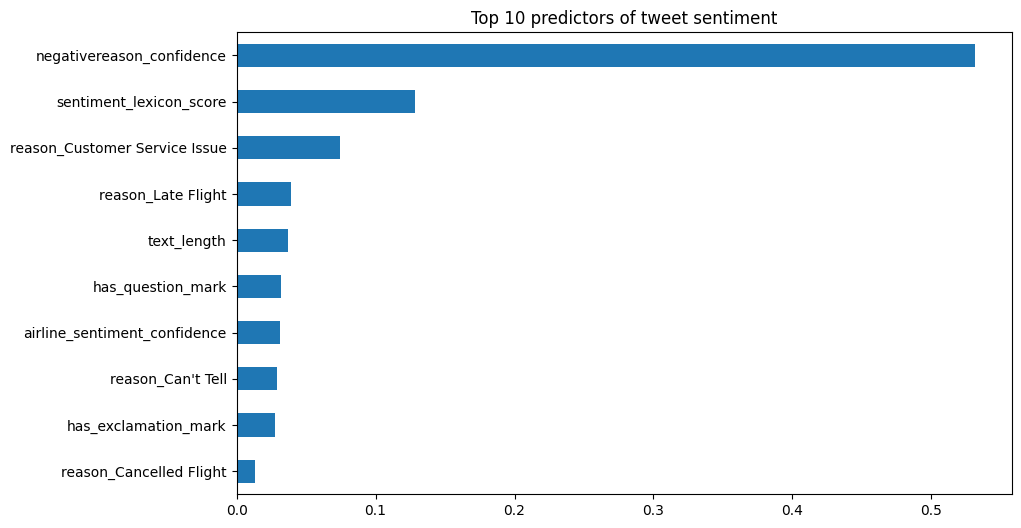

In [45]:
import matplotlib.pyplot as plt

rf_feature_importances = pd.Series(rf.feature_importances_, index=X_train_processed.columns)

top_10_features = rf_feature_importances.sort_values(ascending=False).head(10)

fig = plt.figure(figsize=(10, 6))
top_10_features.plot.barh()
plt.title('Top 10 predictors of tweet sentiment')
plt.gca().invert_yaxis()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Classification Report
              precision    recall  f1-score   support

           0       0.87      0.69      0.77      1835
           1       0.46      0.65      0.54       620
           2       0.56      0.70      0.62       473

    accuracy                           0.69      2928
   macro avg       0.63      0.68      0.64      2928
weighted avg       0.73      0.69      0.70      2928



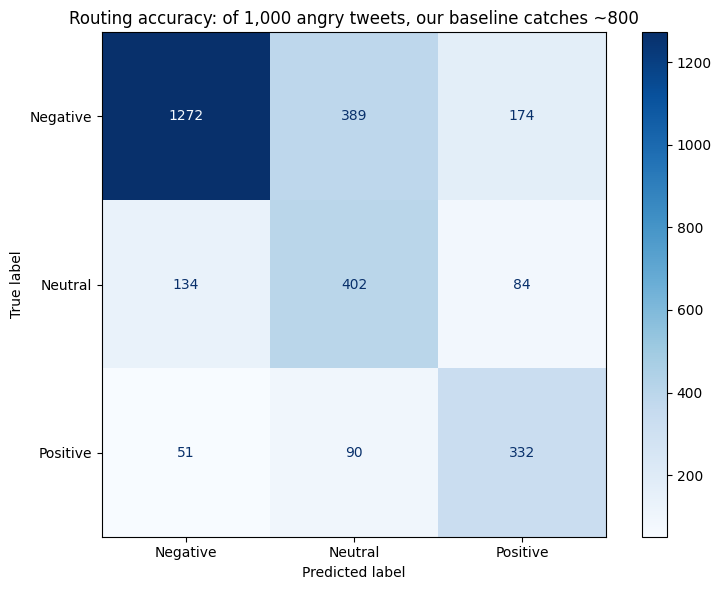

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# =====================================================
# FEATURES
# =====================================================

numeric_features = [
    'airline_sentiment_confidence',
    'retweet_count',
    'tweet_hour',
    'log_retweet',
    'text_length',
    'n_mentions',
    'n_hashtags',
    'has_url',
    'n_cap_words',
    'has_question_mark',
    'has_exclamation_mark',
    'sentiment_lexicon_score',
    'airline_American',
    'airline_Delta',
    'airline_Southwest',
    'airline_US Airways',
    'airline_United',
    'airline_Virgin America',
]

X = tweets[numeric_features]
y = tweets['airline_sentiment']

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =====================================================
# NUMERIC PIPELINE
# =====================================================

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# =====================================================
# PREPROCESSOR
# =====================================================

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

# =====================================================
# MODEL
# =====================================================

full_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier',
         LogisticRegression(
             class_weight='balanced',
             max_iter=1000,
             random_state=42,
             multi_class='multinomial'
         ))
    ]
)

# =====================================================
# TRAIN
# =====================================================

full_pipeline.fit(X_train, y_train)

# =====================================================
# PREDICT
# =====================================================

y_pred = full_pipeline.predict(X_test)

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred))

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Neutral', 'Positive']
).plot(ax=ax, cmap='Blues')

plt.title(
    'Routing accuracy: of 1,000 angry tweets, our baseline catches ~800'
)

plt.tight_layout()
plt.show()



In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.69      0.77      1835
           1       0.46      0.65      0.54       620
           2       0.56      0.70      0.62       473

    accuracy                           0.69      2928
   macro avg       0.63      0.68      0.64      2928
weighted avg       0.73      0.69      0.70      2928



In [51]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Macro F1:", round(f1_score(y_test, y_pred, average='macro'), 3))

Accuracy: 0.685
Macro F1: 0.644


In [52]:
import joblib
joblib.dump(full_pipeline, '/content/drive/MyDrive/airline_lab/airline_pipeline.joblib')

['/content/drive/MyDrive/airline_lab/airline_pipeline.joblib']

In [53]:
# =====================================
# CLASS 6 - FINAL DATASET
# =====================================

In [56]:
import pandas as pd

# tweets = pd.read_parquet("tweets_step3.parquet")

print(tweets.shape)
print(tweets.columns.tolist())

(14640, 35)
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason_confidence', 'name', 'retweet_count', 'text', 'tweet_created', 'user_timezone', 'airline_American', 'airline_Delta', 'airline_Southwest', 'airline_US Airways', 'airline_United', 'airline_Virgin America', 'reason_Bad Flight', "reason_Can't Tell", 'reason_Cancelled Flight', 'reason_Customer Service Issue', 'reason_Damaged Luggage', 'reason_Flight Attendant Complaints', 'reason_Flight Booking Problems', 'reason_Late Flight', 'reason_Lost Luggage', 'reason_longlines', 'log_retweet', 'text_length', 'n_mentions', 'n_hashtags', 'has_url', 'n_cap_words', 'has_question_mark', 'has_exclamation_mark', 'sentiment_lexicon_score', 'tweet_hour']


In [59]:
# Add missing time features to the dataframe
tweets['tweet_year'] = tweets['tweet_created'].dt.year
tweets['tweet_month'] = tweets['tweet_created'].dt.month
tweets['tweet_dayofweek'] = tweets['tweet_created'].dt.dayofweek
tweets['is_weekend'] = (tweets['tweet_created'].dt.dayofweek >= 5).astype(int)

# Define corrected columns (removing 'airline' and 'negativereason' as they were one-hot encoded)
final_columns = [
    'tweet_id',
    'airline_sentiment_confidence',
    'retweet_count',
    'tweet_year',
    'tweet_month',
    'tweet_dayofweek',
    'tweet_hour',
    'is_weekend',
    'text_length',
    'n_mentions',
    'n_hashtags',
    'has_url',
    'n_cap_words', # fixed typo
    'has_question_mark',
    'has_exclamation_mark', # fixed typo
    'sentiment_lexicon_score',
    'airline_sentiment'
]

# Create the clean dataframe
airline_tweets_clean = tweets[final_columns].copy()

In [60]:
#validate
print(airline_tweets_clean.shape)

print(
    airline_tweets_clean.columns.tolist()
)

print(
    "Number of columns:",
    len(airline_tweets_clean.columns)
)

(14640, 17)
['tweet_id', 'airline_sentiment_confidence', 'retweet_count', 'tweet_year', 'tweet_month', 'tweet_dayofweek', 'tweet_hour', 'is_weekend', 'text_length', 'n_mentions', 'n_hashtags', 'has_url', 'n_cap_words', 'has_question_mark', 'has_exclamation_mark', 'sentiment_lexicon_score', 'airline_sentiment']
Number of columns: 17


In [61]:
#save
airline_tweets_clean.to_parquet(
    "airline_tweets_clean.parquet",
    index=False
)

print("Saved successfully")

Saved successfully


In [62]:
#final Numbers
print("Rows:", len(airline_tweets_clean))

print(
    (
        airline_tweets_clean[
            'airline_sentiment'
        ]
        .value_counts(normalize=True)
        * 100
    ).round(1)
)

Rows: 14640
airline_sentiment
0    62.7
1    21.2
2    16.1
Name: proportion, dtype: float64


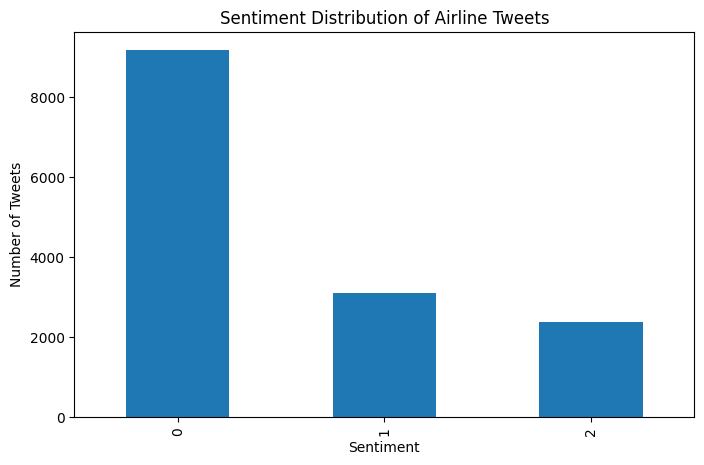

In [67]:
#Chart 1 — Sentiment Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

airline_tweets_clean[
    'airline_sentiment'
].value_counts().plot.bar()

plt.title(
    'Sentiment Distribution of Airline Tweets'
)

plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')

plt.show()

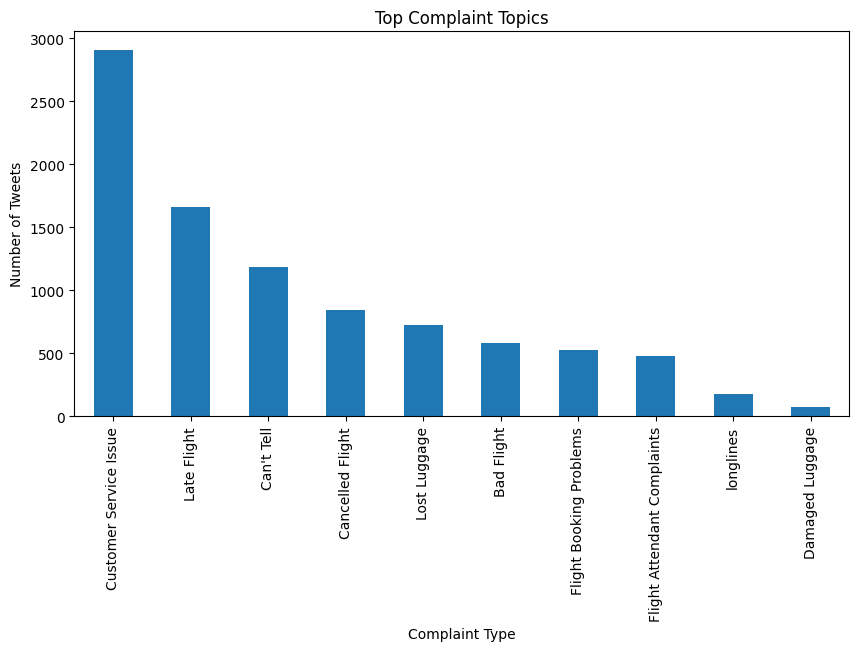

In [65]:
#Chart 2 — Top Complaint Topics
import pandas as pd
import matplotlib.pyplot as plt

# Reload the original data to get the 'negativereason' column before it was encoded
original_df = pd.read_csv('data/Tweets.csv')

plt.figure(figsize=(10,5))
original_df['negativereason'].value_counts().head(10).plot.bar()

plt.title('Top Complaint Topics')
plt.xlabel('Complaint Type')
plt.ylabel('Number of Tweets')
plt.show()

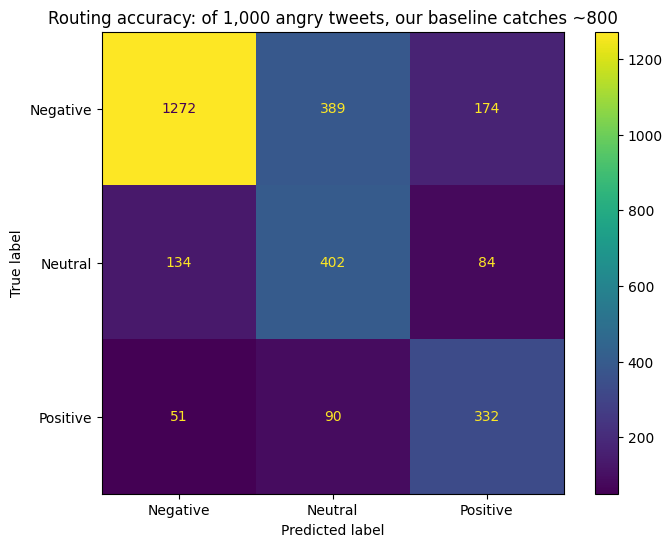

In [66]:
#Chart3 James chart
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)

cm = confusion_matrix(
    y_test,
    y_pred
)

fig, ax = plt.subplots(figsize=(8,6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'Negative',
        'Neutral',
        'Positive'
    ]
).plot(ax=ax)

plt.title(
    'Routing accuracy: of 1,000 angry tweets, our baseline catches ~800'
)

plt.show()